In [8]:
# Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for a cleaner notebook presentation
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv("May-2022.csv")
print(f"Original Dataset Shape: {df.shape}")

# Convert text to numeric, coercing errors to NaN
numeric_columns = [
    "Weight", "TP", "MRP Old", "Final MRP Old", "Ajio MRP", "Amazon MRP", 
    "Amazon FBA MRP", "Flipkart MRP", "Limeroad MRP", "Myntra MRP", 
    "Paytm MRP", "Snapdeal MRP"
]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing values and create a distinct cleaned dataframe
df_cleaned = df.dropna().copy()
print(f"Cleaned Dataset Shape: {df_cleaned.shape}")

# Verify duplicates are handled
print(f"Duplicate rows: {df_cleaned.duplicated().sum()}")
print(f"Duplicate SKUs: {df_cleaned['Sku'].duplicated().sum()}")

Original Dataset Shape: (1330, 17)
Cleaned Dataset Shape: (1221, 17)
Duplicate rows: 0
Duplicate SKUs: 0


In [3]:
# Calculate Markup and Markup Percentage
df_cleaned["Markup"] = df_cleaned["Final MRP Old"] - df_cleaned["TP"]
df_cleaned["Markup %"] = (df_cleaned["Markup"] / df_cleaned["TP"]) * 100

# Calculate Q1, Q3, and IQR for Final MRP Old
Q1 = df_cleaned["Final MRP Old"].quantile(0.25)
Q3 = df_cleaned["Final MRP Old"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create an outlier flag column
df_cleaned["Price_Outlier"] = (df_cleaned["Final MRP Old"] < lower_bound) | (df_cleaned["Final MRP Old"] > upper_bound)
print(f"Number of price outliers detected: {df_cleaned['Price_Outlier'].sum()}")

Number of price outliers detected: 41


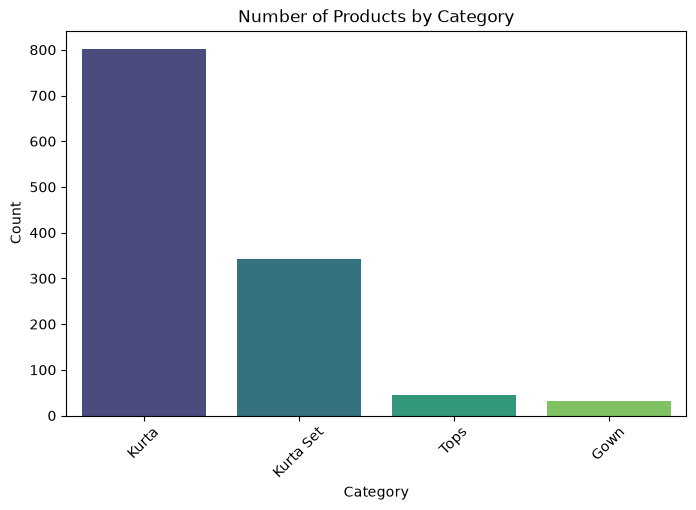

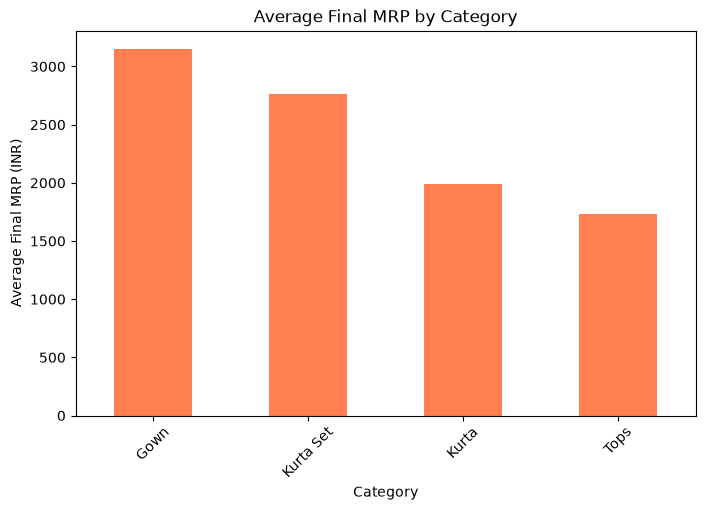

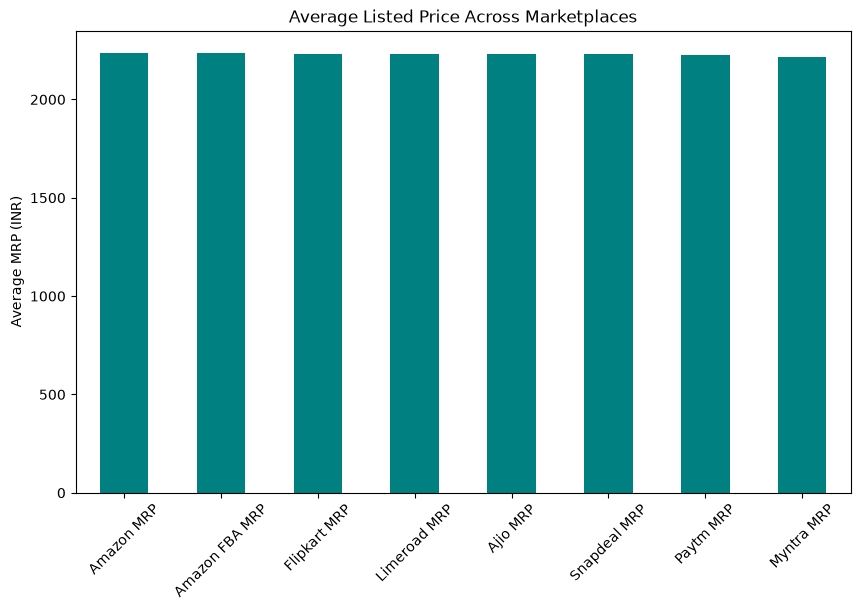

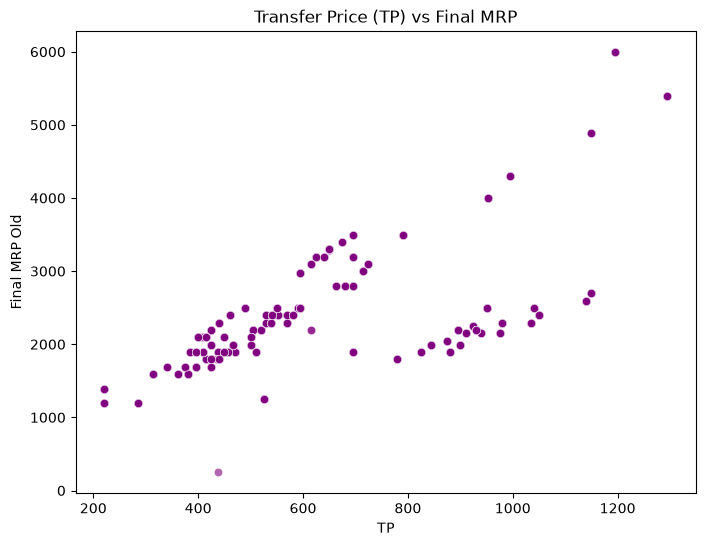

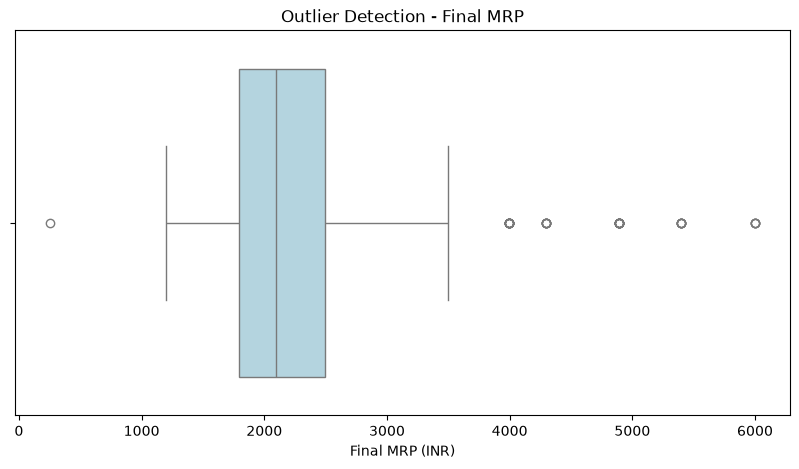

Data successfully exported to cleaned_data.csv


In [4]:
# 1. Category Distribution
category_counts = df_cleaned["Category"].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, palette="viridis", legend=False)
plt.title("Number of Products by Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 2. Average Final MRP by Category
avg_mrp_category = df_cleaned.groupby("Category")["Final MRP Old"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
avg_mrp_category.plot(kind="bar", color="coral")
plt.title("Average Final MRP by Category")
plt.ylabel("Average Final MRP (INR)")
plt.xticks(rotation=45)
plt.show()

# 3. Marketplace Pricing Comparison
marketplace_columns = ["Ajio MRP", "Amazon MRP", "Amazon FBA MRP", "Flipkart MRP", "Limeroad MRP", "Myntra MRP", "Paytm MRP", "Snapdeal MRP"]
marketplace_avg = df_cleaned[marketplace_columns].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
marketplace_avg.plot(kind="bar", color="teal")
plt.title("Average Listed Price Across Marketplaces")
plt.ylabel("Average MRP (INR)")
plt.xticks(rotation=45)
plt.show()

# 4. Transfer Price vs Final MRP
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cleaned, x="TP", y="Final MRP Old", alpha=0.6, color="purple")
plt.title("Transfer Price (TP) vs Final MRP")
plt.show()

# 5. Outlier Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_cleaned["Final MRP Old"], color="lightblue")
plt.title("Outlier Detection - Final MRP")
plt.xlabel("Final MRP (INR)")
plt.show()

# 6. Final Export
df_cleaned.to_csv("cleaned_data.csv", index=False)
print("Data successfully exported to cleaned_data.csv")